In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image


2026-03-16 14:16:15.329017: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 14:16:15.642887: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 14:16:17.652389: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
CSV_PATH = "../data/inverse_rendering_dataset/metadata.csv"
DATASET_ROOT = "../data/inverse_rendering_dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
np.random.seed(42)
tf.random.set_seed(42)


In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)

df = df[
    (df["num_active_lights"].astype(int) == 1)
    & (df["light0_type"].astype(str) == "SPOT")
    & (df["batch_folder"].astype(str).str.contains("spot_size", case=False, na=False))
].copy()

df["image_path"] = df["image_relpath"].astype(str).apply(lambda p: os.path.join(DATASET_ROOT, p))
df = df[df["image_path"].map(os.path.exists)].reset_index(drop=True)

if df.empty:
    raise ValueError("No spot-size rows found with existing images. Check CSV_PATH/DATASET_ROOT.")

print("Rows with existing spot-size images:", len(df))
print("Spot cone range (deg):", float(df["light0_spot_cone_deg"].min()), float(df["light0_spot_cone_deg"].max()))


Rows with existing spot-size images: 480
Spot cone range (deg): 12.094981798302266 64.98926361304966


In [4]:
def load_and_preprocess_image(path: str) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0

X_images = np.stack([load_and_preprocess_image(p) for p in df["image_path"]], axis=0)
print("Image tensor shape:", X_images.shape)


Image tensor shape: (480, 128, 128, 3)


In [5]:
target_col = "light0_spot_cone_deg"
y_raw = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_val = train_test_split(idx_train, test_size=0.2, random_state=42)

X_train, X_val, X_test = X_images[idx_train], X_images[idx_val], X_images[idx_test]
y_train_raw, y_val_raw, y_test_raw = y_raw[idx_train], y_raw[idx_val], y_raw[idx_test]

y_mean = y_train_raw.mean(axis=0, keepdims=True)
y_std = y_train_raw.std(axis=0, keepdims=True)
y_std[y_std < 1e-8] = 1.0

y_train = (y_train_raw - y_mean) / y_std
y_val = (y_val_raw - y_mean) / y_std
y_test = (y_test_raw - y_mean) / y_std

print("Train/Val/Test:", len(idx_train), len(idx_val), len(idx_test))


Train/Val/Test: 307 77 96


In [6]:
img_input = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = layers.Conv2D(32, 3, activation="relu", padding="same")(img_input)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

spot_out = layers.Dense(1, name="spot_size_head")(x)

model = keras.Model(inputs=img_input, outputs=spot_out)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"],
)
model.summary()

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)


W0000 00:00:1773684984.398799    7579 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spot_size_head (Dense)          │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 0.9962 - mae: 0.8776 - val_loss: 1.1684 - val_mae: 0.9558
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.9630 - mae: 0.8603 - val_loss: 1.1599 - val_mae: 0.9413
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.9457 - mae: 0.8515 - val_loss: 1.0977 - val_mae: 0.9260
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.8833 - mae: 0.8208 - val_loss: 1.0102 - val_mae: 0.8655
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.7988 - mae: 0.7789 - val_loss: 0.8626 - val_mae: 0.7920
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.6986 - mae: 0.7130 - val_loss: 0.7879 - val_mae: 0.7516
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.5910 - mae: 0.6354 - val_loss: 0.6676 - val_mae: 0.6783
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.5183 - mae: 0.5665 - val_loss: 0.5854 - val_mae: 0.6351
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/

Test loss (z-space): 0.328886
Test MAE (z-space): 0.385490
Spot size MAE (deg): 6.075
Spot size RMSE (deg): 9.037


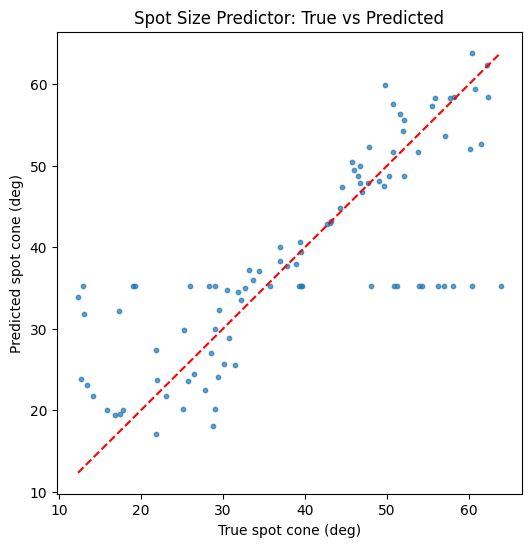

In [7]:
test_loss, test_mae_z = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss (z-space): {test_loss:.6f}")
print(f"Test MAE (z-space): {test_mae_z:.6f}")

y_pred_z = model.predict(X_test, verbose=0)

y_pred = y_pred_z * y_std + y_mean
y_true = y_test_raw

mae_deg = np.mean(np.abs(y_pred[:, 0] - y_true[:, 0]))
rmse_deg = np.sqrt(np.mean((y_pred[:, 0] - y_true[:, 0]) ** 2))
print(f"Spot size MAE (deg): {mae_deg:.3f}")
print(f"Spot size RMSE (deg): {rmse_deg:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_true[:, 0], y_pred[:, 0], s=10, alpha=0.7)
mn = float(min(y_true[:, 0].min(), y_pred[:, 0].min()))
mx = float(max(y_true[:, 0].max(), y_pred[:, 0].max()))
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("True spot cone (deg)")
plt.ylabel("Predicted spot cone (deg)")
plt.title("Spot Size Predictor: True vs Predicted")
plt.show()


In [8]:
# save model for later testing
model.save("spot_size_predictor.keras")

# single image inference + comparison
sample_idx = int(idx_test[0])
sample_path = df.iloc[sample_idx]["image_path"]
sample_relpath = df.iloc[sample_idx]["image_relpath"]

sample_img = np.expand_dims(load_and_preprocess_image(sample_path), axis=0)
pred_z = model.predict(sample_img, verbose=0)
pred_spot_deg = float((pred_z * y_std + y_mean)[0, 0])

true_spot_deg = float(df.iloc[sample_idx][target_col])

print("Image:", sample_relpath)
print(f"Predicted spot cone (deg): {pred_spot_deg:.3f}")
print(f"True spot cone (deg):      {true_spot_deg:.3f}")
print(f"Absolute error (deg):      {abs(pred_spot_deg - true_spot_deg):.3f}")


Image: images/single_light/spot_size/rand_spot_00/000673_az015_el-05.png
Predicted spot cone (deg): 43.151
True spot cone (deg):      43.205
Absolute error (deg):      0.055
